# Class Distribution: 59 Original Classes vs 9 Superclasses

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

from configs import config
from class_mapping import remap_mask, load_superclass_names, NUM_SUPERCLASSES



In [3]:
RAW_DIR = os.path.join(config.DATA_ROOT, "0_raw")
MASKS_DIR = os.path.join(RAW_DIR, "png_masks", "MASKS")
labels_df = pd.read_csv(os.path.join(RAW_DIR, "labels.csv"))
class_names_59 = labels_df.iloc[:, -1].tolist()

## Count pixels per class across a sample of masks


In [4]:
SAMPLE_SIZE = 200

mask_files = sorted(os.listdir(MASKS_DIR))[:SAMPLE_SIZE]

pixel_counts_59 = np.zeros(59, dtype=np.int64)
pixel_counts_9 = np.zeros(NUM_SUPERCLASSES, dtype=np.int64)

for fname in tqdm(mask_files):
    mask = cv2.imread(os.path.join(MASKS_DIR, fname), cv2.IMREAD_GRAYSCALE)
    vals, counts = np.unique(mask, return_counts=True)
    for v, c in zip(vals, counts):
        if v < 59:
            pixel_counts_59[v] += c

    remapped = remap_mask(mask)
    vals9, counts9 = np.unique(remapped, return_counts=True)
    for v, c in zip(vals9, counts9):
        pixel_counts_9[v] += c

100%|██████████| 200/200 [00:43<00:00,  4.58it/s]


## Original 59-class distribution


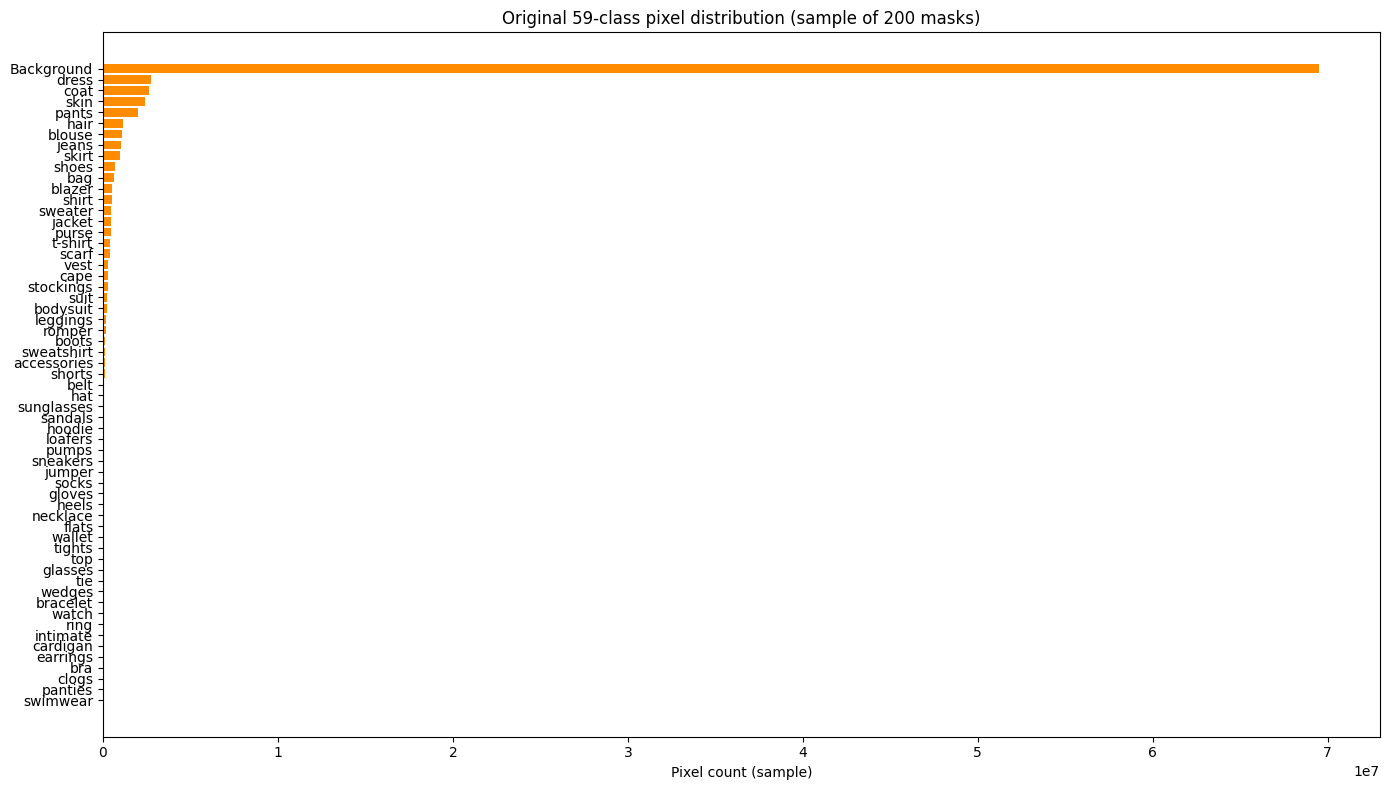

In [10]:
class_pixel_df = pd.DataFrame({
    "class_name": class_names_59,
    "pixel_count": pixel_counts_59,
})

class_pixel_df['class_name'] = class_pixel_df['class_name'].fillna('Background')
class_pixel_df = class_pixel_df.sort_values("pixel_count", ascending=False)

plt.figure(figsize=(14, 8))
plt.barh(class_pixel_df["class_name"], class_pixel_df["pixel_count"], color="darkorange")
plt.gca().invert_yaxis()
plt.xlabel("Pixel count (sample)")
plt.title(f"Original 59-class pixel distribution (sample of {SAMPLE_SIZE} masks)")
plt.tight_layout()
plt.show()

## Remapped 9-superclass distribution


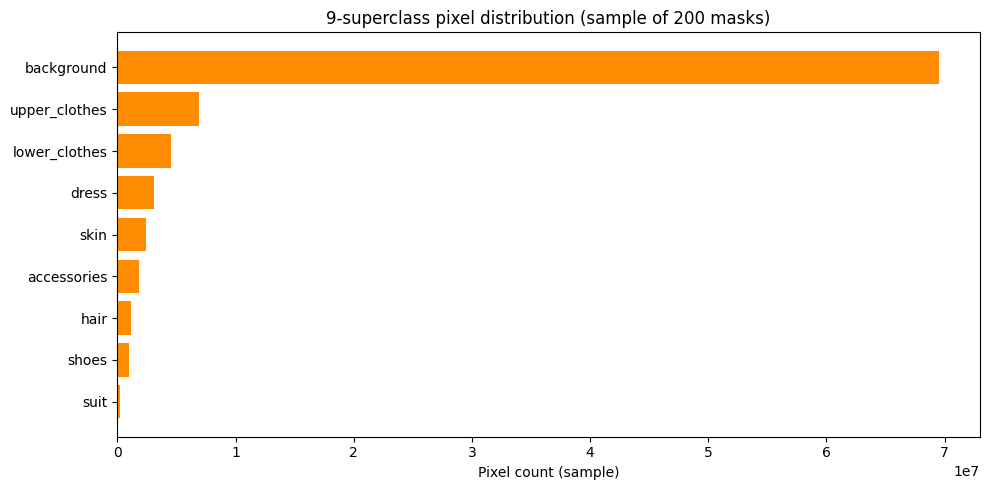

In [11]:
superclass_names = load_superclass_names()

superclass_df = pd.DataFrame({
    "superclass": superclass_names,
    "pixel_count": pixel_counts_9,
}).sort_values("pixel_count", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(superclass_df["superclass"], superclass_df["pixel_count"], color="darkorange")
plt.gca().invert_yaxis()
plt.xlabel("Pixel count (sample)")
plt.title(f"9-superclass pixel distribution (sample of {SAMPLE_SIZE} masks)")
plt.tight_layout()
plt.show()